AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Class distribution: Counter({0: 219, 1: 101})
Tuning models once on roc_auc ...
  [Logistic Regression] roc_auc=0.545: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
  [Decision Tree] roc_auc=0.546: {'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 4}
  [Random Forest] roc_auc=0.536: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
  [Support Vector Machine] roc_auc=0.558: {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
  [K-Nearest Neighbors] roc_auc=0.541: {'n_neighbors': 7, 'p': 2, 'weights': 'uniform'}
Tuning DNN once on roc_auc ...

  [Deep Neural Network] roc_auc=0.527: {'batch_size': 32, 'epochs': 50, 'model__optimizer': 'rmsprop', 'model__units1': 12, 'model__units2': 6}
Processing DNN Fold 1...
Processing DNN Fold 2...
Processing DNN Fold 3...
Processing DNN Fold 4...
Processing DNN Fold 5...
Processing DNN Fold 6...
Processing DNN Fold 7...
Processing DNN F

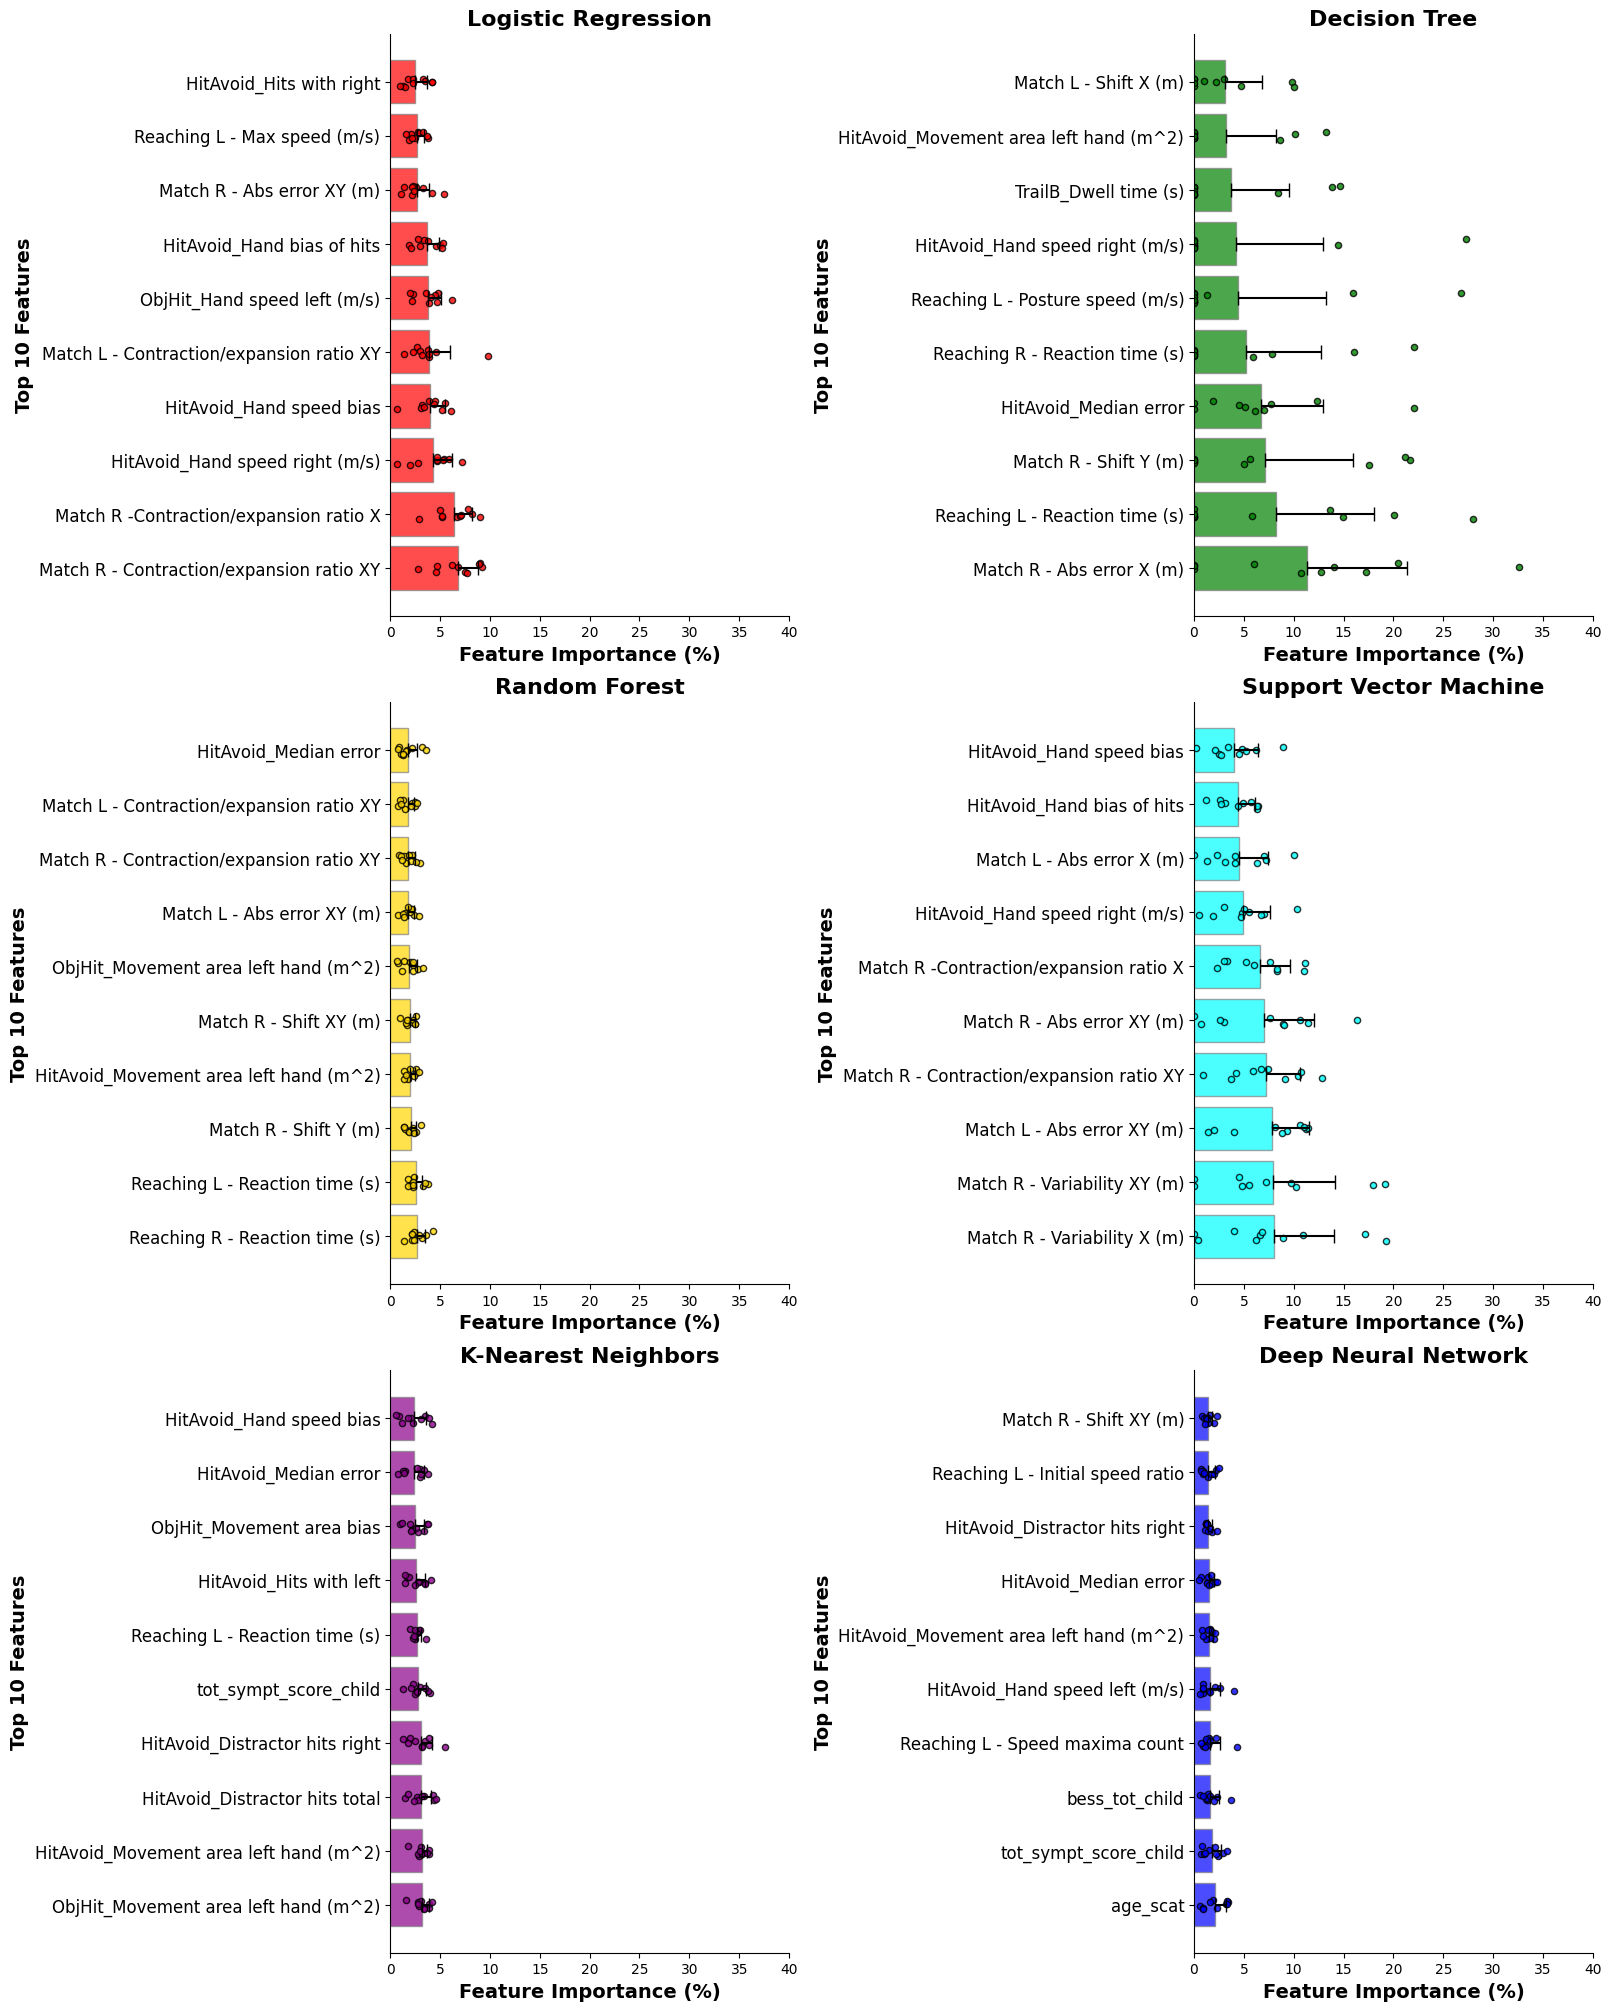

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input
from collections import Counter
import shap
import os
import warnings
warnings.filterwarnings("ignore")

# Load and merge datasets
Yes_Concussion = pd.read_csv('S2P_Combined_WithHistory_20260111_TC.csv')
No_Concussion = pd.read_csv('S2P_Combined_NoHistory_20260111_TC.csv')

# Hard-code labels
Yes_Concussion['data_type'] = 1   # Concussion
No_Concussion['data_type'] = 0    # No_Concussion

# Merge datasets
datas = pd.concat([Yes_Concussion, No_Concussion], ignore_index=True)

# Prepare features and labels
X_data = datas.iloc[:, :-1]
y = datas.iloc[:, -1].values

stp_feature_names = list(X_data.columns)  # <-- Add this line

# Data normalization
ss = StandardScaler().fit(X_data)
X = ss.transform(X_data)

# Optional sanity check
print("Class distribution:", Counter(y))

# Reproducibility: seed NumPy and TensorFlow (DNN feature importances were run-to-run unstable)
np.random.seed(42)
tf.random.set_seed(42)

# Initialize cross-validation
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# ---------------------------------------------------------------------------
# Hyper-parameters are selected ONCE on the full dataset with a single objective
# (roc_auc), matching the classification pipeline's rocauc variant; SHAP feature
# importances are then computed from these tuned models (tune-once, then K-fold).
# ---------------------------------------------------------------------------
from sklearn.model_selection import GridSearchCV
from sklearn.base import clone

TUNE_SCORING = "roc_auc"
tune_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

base_models = {
    "Logistic Regression": (LogisticRegression(max_iter=1000),
        {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}),
    "Decision Tree": (DecisionTreeClassifier(random_state=42),
        {'criterion': ['gini', 'entropy'], 'max_depth': [3, 4, 5, 6, 7, None],
         'min_samples_split': [2, 4, 6], 'min_samples_leaf': [1, 2, 3],
         'class_weight': [None, 'balanced']}),
    "Random Forest": (RandomForestClassifier(random_state=42),
        {'n_estimators': [100, 200, 300], 'max_features': ['sqrt', 'log2'],
         'max_depth': [None, 10, 20], 'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2]}),
    "Support Vector Machine": (SVC(probability=True, random_state=42),
        {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto', 0.1], 'kernel': ['linear', 'rbf']}),
    "K-Nearest Neighbors": (KNeighborsClassifier(),
        {'n_neighbors': [3, 5, 7, 9, 11], 'weights': ['uniform', 'distance'], 'p': [1, 2]}),
}

models = {}
print("Tuning models once on roc_auc ...")
for _name, (_est, _grid) in base_models.items():
    _gs = GridSearchCV(_est, _grid, scoring=TUNE_SCORING, cv=tune_cv, n_jobs=-1)
    _gs.fit(X, y)
    models[_name] = clone(_est).set_params(**_gs.best_params_)
    print(f"  [{_name}] {TUNE_SCORING}={_gs.best_score_:.3f}: {_gs.best_params_}")

# Output directory for CSV files
csv_output_dir = "Feature_Importance_CSVs"
os.makedirs(csv_output_dir, exist_ok=True)

def save_importance_to_csv(importance_df, model_name, total_variation_mean, total_variation_std, output_dir):
    """
    Save full feature importance DataFrame (all folds + Mean + Std) to a CSV file.
    Appends a summary row for the top-10 cumulative share of total SHAP importance.
    """
    # Clean model name for use as filename
    safe_name = model_name.replace(" ", "_")
    filepath = os.path.join(output_dir, f"{safe_name}_Feature_Importance.csv")

    # Sort by mean importance descending
    export_df = importance_df.sort_values('Mean (%)', ascending=False).copy()
    export_df.index.name = 'Feature'

    # Append a summary row: top-10 cumulative share of total SHAP importance
    summary_row = pd.Series(
        {col: np.nan for col in export_df.columns},
        name='--- Top 10 Cumulative SHAP Importance (%) ---'
    )
    summary_row['Mean (%)'] = total_variation_mean
    summary_row['Std (%)'] = total_variation_std

    export_df = pd.concat([export_df, summary_row.to_frame().T])
    export_df.to_csv(filepath)
    print(f"  -> Saved: {filepath}")


def extract_binary_shap_values(shap_values, positive_class=1):
    """Return |SHAP| for the positive class, consistent across explainer output formats.

    Handles: list outputs (one array per class), 3D arrays (samples x features x classes),
    and 2D arrays (samples x features). Always returns a 2D |SHAP| array.
    """
    if isinstance(shap_values, list):
        if len(shap_values) == 2:
            return np.abs(shap_values[positive_class])
        return np.mean([np.abs(sv) for sv in shap_values], axis=0)
    shap_values = np.asarray(shap_values)
    if shap_values.ndim == 3:
        return np.abs(shap_values[:, :, positive_class])
    return np.abs(shap_values)


# Function to calculate feature importances using SHAP
def calculate_feature_importances(model, X, y, stp_feature_names):
    feature_importances_list = []
    total_variation_per_fold = []  # To store total variation explained per fold
    for train_idx, test_idx in kfold.split(X, y):
        # Train the model
        model.fit(X[train_idx], y[train_idx])

        # Use SHAP to explain the model
        if isinstance(model, SVC) or isinstance(model, KNeighborsClassifier):
            # Representative random background sample (was the first 100 training rows)
            background = shap.sample(X[train_idx], 100, random_state=42)
            explainer = shap.KernelExplainer(model.predict_proba, background)
            shap_values = explainer.shap_values(X[test_idx[:100]], silent=True)  # silent=True: no tqdm widget (avoids 'Error displaying widget')
        elif isinstance(model, (RandomForestClassifier, DecisionTreeClassifier)):
            # tree models -> TreeExplainer; additivity check off (tuned DT may be deep)
            explainer = shap.TreeExplainer(model, X[train_idx], feature_names=stp_feature_names)
            shap_values = explainer.shap_values(X[test_idx], check_additivity=False)
        else:
            explainer = shap.Explainer(model, X[train_idx], feature_names=stp_feature_names)
            shap_values = explainer.shap_values(X[test_idx])

        # Consistent positive-class (class 1) extraction across all explainer outputs
        shap_values = extract_binary_shap_values(shap_values, positive_class=1)

        # Compute mean absolute SHAP values for feature importance
        fea_importance_series = pd.Series(
            shap_values.mean(axis=0),  # Mean across samples
            index=stp_feature_names
        )

        # Normalize feature importances to percentage
        fea_importance_percent = 100 * fea_importance_series / fea_importance_series.sum()
        feature_importances_list.append(fea_importance_percent)

        # Top-10 cumulative share of total normalized SHAP importance (NOT variance explained)
        top_10_features = fea_importance_percent.sort_values(ascending=False).head(10)
        total_variation_per_fold.append(top_10_features.sum())

    # Combine fold results
    importance_df = pd.concat(feature_importances_list, axis=1)
    importance_df.columns = [f'Fold_{i + 1}' for i in range(len(feature_importances_list))]
    importance_df['Mean (%)'] = importance_df.mean(axis=1)
    importance_df['Std (%)'] = importance_df.std(axis=1)

    # Calculate mean and SD of total variation explained across folds
    total_variation_mean = np.mean(total_variation_per_fold)
    total_variation_std = np.std(total_variation_per_fold)

    return importance_df, total_variation_mean, total_variation_std


# Add DNN Model (architecture/optimizer also tuned once on roc_auc, then used per fold)
def create_dnn_model(input_dim, units1=12, units2=8, optimizer='adam'):
    inputs = Input(shape=(input_dim,))
    x = Dense(units1, activation='relu')(inputs)
    x = Dense(units2, activation='relu')(x)
    outputs = Dense(1, activation='sigmoid')(x)
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

from scikeras.wrappers import KerasClassifier

def _dnn_factory(units1=12, units2=8, optimizer='adam'):
    tf.keras.backend.clear_session(); tf.random.set_seed(42)
    return create_dnn_model(X.shape[1], units1=units1, units2=units2, optimizer=optimizer)

from sklearn.metrics import roc_auc_score
def _roc_auc_proba(estimator, X, yt):
    # scikeras KerasClassifier is not recognized by sklearn 1.7's built-in roc_auc
    # scorer, so score it explicitly from predict_proba.
    return roc_auc_score(yt, estimator.predict_proba(X)[:, 1])

print("Tuning DNN once on roc_auc ...")
_dnn_search = GridSearchCV(
    KerasClassifier(model=_dnn_factory, verbose=0),
    {'model__units1': [8, 12], 'model__units2': [6, 8],
     'model__optimizer': ['adam', 'rmsprop'], 'batch_size': [32], 'epochs': [50]},
    scoring=_roc_auc_proba,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42), n_jobs=1)
_dnn_search.fit(X, y)
_b = _dnn_search.best_params_
print(f"  [Deep Neural Network] {TUNE_SCORING}={_dnn_search.best_score_:.3f}: {_b}")
DNN_UNITS1, DNN_UNITS2 = _b['model__units1'], _b['model__units2']
DNN_OPT, DNN_EPOCHS, DNN_BATCH = _b['model__optimizer'], _b['epochs'], _b['batch_size']

# Perform k-fold cross-validation for DNN
shap_importance_list = []
total_variation_per_fold = []  # To store total variation explained per fold
for fold, (train_idx, test_idx) in enumerate(kfold.split(X, y)):
    print(f"Processing DNN Fold {fold + 1}...")
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Build and train the DNN model (tuned roc_auc config)
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)
    dnn_model = create_dnn_model(X.shape[1], units1=DNN_UNITS1, units2=DNN_UNITS2, optimizer=DNN_OPT)
    dnn_model.fit(X_train, y_train, epochs=DNN_EPOCHS, batch_size=DNN_BATCH, verbose=0)

    # Use SHAP to explain the model (DeepExplainer)
    explainer = shap.DeepExplainer(dnn_model, X_train[:100].astype(np.float32))  # Use a subset of training data for background
    shap_values = explainer.shap_values(X_test[:100].astype(np.float32))  # Use a subset of test data for SHAP values

    # Single sigmoid output: DeepExplainer may return a list or a 3D array
    if isinstance(shap_values, list):
        shap_values = shap_values[0]
    shap_values = np.asarray(shap_values)
    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, 0]
    shap_values = np.abs(shap_values).mean(axis=0)

    # Compute mean absolute SHAP values for feature importance
    fea_importance_series = pd.Series(
        shap_values,  # Mean across samples
        index=stp_feature_names
    )

    # Normalize feature importances to percentage
    fea_importance_percent = 100 * fea_importance_series / fea_importance_series.sum()
    shap_importance_list.append(fea_importance_percent)

    # Top-10 cumulative share of total normalized SHAP importance (NOT variance explained)
    top_10_features = fea_importance_percent.sort_values(ascending=False).head(10)
    total_variation_per_fold.append(top_10_features.sum())

# Combine SHAP feature importances from all folds
dnn_importance_df = pd.concat(shap_importance_list, axis=1)
dnn_importance_df.columns = [f'Fold_{i + 1}' for i in range(len(shap_importance_list))]
dnn_importance_df['Mean (%)'] = dnn_importance_df.mean(axis=1)
dnn_importance_df['Std (%)'] = dnn_importance_df.std(axis=1)

# Calculate mean and SD of total variation explained across folds
dnn_total_variation_mean = np.mean(total_variation_per_fold)
dnn_total_variation_std = np.std(total_variation_per_fold)

# Combine with other models
feature_importances = {}
total_variations = {}  # To store total variation explained for each model
for model_name, model in models.items():
    print(f"Processing {model_name}...")
    importance_df, total_variation_mean, total_variation_std = calculate_feature_importances(model, X, y, stp_feature_names)
    feature_importances[model_name] = importance_df
    total_variations[model_name] = (total_variation_mean, total_variation_std)

# Add DNN results
feature_importances["Deep Neural Network"] = dnn_importance_df
total_variations["Deep Neural Network"] = (dnn_total_variation_mean, dnn_total_variation_std)

# -----------------------------------------------------------------------
# Save each model's feature importance to a separate CSV file
# -----------------------------------------------------------------------
print("\nSaving feature importance CSV files...")
for model_name, importance_df in feature_importances.items():
    total_variation_mean, total_variation_std = total_variations[model_name]
    save_importance_to_csv(importance_df, model_name, total_variation_mean, total_variation_std, csv_output_dir)

# Select top 10 features for each model
top_features = {}
for model_name, importance_df in feature_importances.items():
    top_features[model_name] = importance_df.sort_values('Mean (%)', ascending=False).head(10)

# Print total variation explained for each model
print("\nTop 10 Cumulative SHAP Importance by Model (Mean ± SD), %:")
for model_name, (mean, std) in total_variations.items():
    print(f"{model_name}: {mean:.2f} ± {std:.2f}")

# Plot all models in a single figure with subplots
fig, axes = plt.subplots(3, 2, figsize=(16, 20), constrained_layout=True)
axes = axes.flatten()

# Colors for each model
colors = {
    "Logistic Regression": 'red',
    "Decision Tree": 'green',
    "Random Forest": 'gold',
    "Support Vector Machine": 'cyan',
    "K-Nearest Neighbors": 'darkmagenta',
    "Deep Neural Network": 'blue'
}

# Plot each model's feature importance
for i, (model_name, top_model_features) in enumerate(top_features.items()):
    ax = axes[i]
    y_positions = np.arange(len(top_model_features))  # Y-axis positions for bars

    # Horizontal bar graph (mean importance)
    bars = ax.barh(
        y_positions,
        top_model_features['Mean (%)'],
        xerr=[np.zeros_like(top_model_features['Std (%)']), top_model_features['Std (%)']],  # One-sided error bars
        capsize=5,
        error_kw={'elinewidth': 1.5, 'ecolor': 'black'},  # Black error bar lines
        color=colors[model_name],
        edgecolor='gray',
        alpha=0.7,
        label='Mean Importance'
    )

    # Add jittered scatter plot
    np.random.seed(42)  # For reproducibility
    jitter_offset = 0.1  # Small vertical offset
    for j, feature in enumerate(top_model_features.index):
        fold_values = feature_importances[model_name].loc[feature, feature_importances[model_name].columns[:-2]]
        y_jitter = np.random.uniform(-jitter_offset, jitter_offset, size=len(fold_values))
        ax.scatter(
            fold_values,
            [y_positions[j] + y_jitter[k] for k in range(len(fold_values))],  # Apply jitter to y
            facecolor=colors[model_name],
            edgecolor='black',
            s=20,
            alpha=0.8,
            linewidth=1,
            label='Individual Folds' if j == 0 else None
        )

    # Clean plot aesthetics
    ax.set_title(model_name, fontsize=16, fontweight='bold')
    ax.set_xlabel('Feature Importance (%)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Top 10 Features', fontsize=14, fontweight='bold')
    ax.set_yticks(y_positions)
    ax.set_yticklabels(top_model_features.index, fontsize=12, rotation=0, ha='right')  # Keep horizontal for readability

    # Remove top and right spines for cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.set_xlim(0, 40)  # Set x-axis limit

# Hide unused subplot (if any)
if len(top_features) < len(axes):
    for j in range(len(top_features), len(axes)):
        axes[j].axis('off')

# Save the combined figure in EPS format
plt.savefig("Stratified_K-Fold_Combined_Model_Feature_Importance_20052026.jpeg", format='jpeg', dpi=600, bbox_inches='tight')
plt.savefig("Stratified_K-Fold_Combined_Model_Feature_Importance_20052026.png", format='png', dpi=600, bbox_inches='tight')

# Show the plot
plt.show()